# Hands-on: can a team of models beat a single model?

**SDS ML Workshop, about 30 minutes**

You will predict how much sleep debt a person has from their evening habits. First you fit four
single models, then you combine them into a **stacked ensemble** and see whether the team beats one
model on its own.

**How to use this notebook**
1. Run the cells from top to bottom (Shift + Enter).
2. Only edit cells marked **YOUR TURN**. Everything else is already set up.
3. Before handing in, use **Runtime > Restart and Run All** (Colab) or **Kernel > Restart and Run All**
   (Jupyter) to check everything still runs.

**Rules**
- Judge your models only with the CV score printed in this notebook.
- Do not touch the test split. It is kept aside for the facilitator.
- No external data.

In [1]:
# Install the two libraries Colab may not have
!pip install -q xgboost kagglehub
!python3 -m pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


## 1. Setup (do not edit)

**The task:** predict `sleep_debt_category`, one of Optimal Recovery, Mild Deficit, Moderate Debt or
Severe Sleep Debt.

**The score:** macro F1, an average score across the 4 categories where each counts equally, so rare
ones like Severe Sleep Debt matter. 1.0 is perfect.

**Why some columns are removed:** the category is a simple rule on `total_sleep_hours` and
`next_day_fatigue_score`. Those two columns alone give about 100% accuracy, so keeping them would turn
the challenge into copying the answer. We also drop `user_id`, which is just a label. The data is
probably synthetic, so treat the results as practice, not science.

**How we score fairly:** cross-validation (CV) splits the training data into 5 parts, trains on 4 and
tests on the 5th, five times over. You get an average score (mean) and how much it wobbles (std).

In [2]:
# Imports and settings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

SEED = 42
BASELINE = "knn"     # alternative: "rf"
FACILITATOR = False  # facilitator only

In [3]:
# Load the data, drop the leaky columns, split 80/20 and set up the scoring tool
DATA_FILE = "bedtime_screentime_sleep_debt.csv"
if os.path.exists(DATA_FILE):
    df = pd.read_csv(DATA_FILE)
else:
    import kagglehub  # only needed when the CSV is not next to this notebook
    folder = kagglehub.dataset_download("samartalwar/sleep-debt-and-screen-time-late-night-phone-habits")
    df = pd.read_csv(os.path.join(folder, DATA_FILE))

CLASS_NAMES = ["Optimal Recovery", "Mild Deficit", "Moderate Debt", "Severe Sleep Debt"]
LABELS = {name: i for i, name in enumerate(CLASS_NAMES)}  # XGBoost needs numbers, not words
NUMERIC = ["age", "bedtime_phone_minutes", "screen_brightness_pct", "blue_light_filter_active",
           "caffeine_post_5pm_mg", "physical_activity_min", "sleep_latency_min",
           "deep_sleep_pct", "rem_sleep_pct", "morning_alarm_snoozes"]
CATEGORICAL = ["gender", "occupation_type", "chronotype", "primary_bedtime_app"]

df = df.drop(columns=["user_id", "total_sleep_hours", "next_day_fatigue_score"])
X = df[NUMERIC + CATEGORICAL]
y = df["sleep_debt_category"].map(LABELS)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)


def pipe(model):
    # Scale the numbers and one-hot the categories, then fit the model
    prep = ColumnTransformer([("num", StandardScaler(), NUMERIC),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])
    return Pipeline([("prep", prep), ("model", model)])


def cv_score(model):
    # 5-fold CV macro F1 on the TRAIN split only. Returns (mean, std)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    s = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    return s.mean(), s.std()


print(f"Training rows: {len(X_train)}, test rows kept aside: {len(X_test)}")
print(y_train.map(dict(enumerate(CLASS_NAMES))).value_counts(normalize=True).round(2))

Training rows: 6800, test rows kept aside: 1700
sleep_debt_category
Moderate Debt        0.52
Mild Deficit         0.24
Optimal Recovery     0.16
Severe Sleep Debt    0.08
Name: proportion, dtype: float64


## 2. The baseline (do not edit)

This is the single model you are trying to beat. Its CV score is the bar for everything below.

In [4]:
# Build the baseline and score it with CV
if BASELINE == "rf":
    baseline = pipe(RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))
else:
    baseline = pipe(KNeighborsClassifier())
baseline_mean, baseline_std = cv_score(baseline)
print(f"Baseline ({BASELINE}): CV macro F1 = {baseline_mean:.3f} +/- {baseline_std:.3f}")

Baseline (knn): CV macro F1 = 0.632 +/- 0.016


## 3. Part A: fit four single models

Each cell below already runs as it is. **YOUR TURN:** change at most one setting per model, then
rerun the scoring cell at the end of Part A.

**KNN:** asks the 5 most similar people in the training data and takes a vote.

In [5]:
# YOUR TURN: KNN. Try n_neighbors between 3 and 40
knn = pipe(KNeighborsClassifier(n_neighbors=5))

**Decision Tree:** asks a chain of yes or no questions ("caffeine after 5pm over 100 mg?") and
follows the answers to a category. `max_depth` is how many questions it may ask in a row.

In [6]:
# YOUR TURN: Decision Tree. Try max_depth between 3 and 8
tree = pipe(DecisionTreeClassifier(max_depth=5, random_state=SEED))

**Random Forest:** grows many different trees on random slices of the data, and they vote.

In [7]:
# YOUR TURN: Random Forest. Try n_estimators between 50 and 200, or max_depth between 5 and 15
forest = pipe(RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))

**XGBoost:** builds small trees one after another, each one fixing the mistakes of the trees before it.

In [8]:
# YOUR TURN: XGBoost. Try n_estimators 50 to 200, max_depth 2 to 6, or learning_rate 0.02 to 0.2
xgb = pipe(XGBClassifier(n_estimators=120, max_depth=3, learning_rate=0.05, subsample=0.9,
                         colsample_bytree=0.9, random_state=SEED, n_jobs=-1))

,CV mean,CV std,vs baseline
XGBoost,0.727,0.016,0.095
Random Forest,0.724,0.010,0.091
Decision Tree,0.704,0.020,0.072
KNN,0.632,0.016,0.000


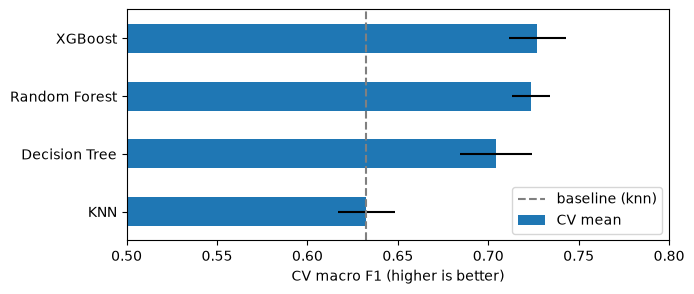

In [9]:
# Score all four models with CV and compare them (about 30 seconds)
models = {"KNN": knn, "Decision Tree": tree, "Random Forest": forest, "XGBoost": xgb}
scores = {name: cv_score(m) for name, m in models.items()}

results = pd.DataFrame(scores, index=["CV mean", "CV std"]).T.sort_values("CV mean", ascending=False)
results["vs baseline"] = results["CV mean"] - baseline_mean
display(results.round(3))

ax = results["CV mean"].iloc[::-1].plot.barh(xerr=results["CV std"].iloc[::-1], color="C0", figsize=(7, 3))
ax.axvline(baseline_mean, ls="--", color="grey", label=f"baseline ({BASELINE})")
ax.set_xlim(0.5, 0.8)
ax.set_xlabel("CV macro F1 (higher is better)")
ax.legend()
plt.show()

**Think about it:** which single model is best? Does any single model beat the baseline by more
than its std (the wobble)?

## 4. Part B: build a stacked ensemble

Each model gives its opinion: a probability for each category. A final simple model, the
**meta-learner**, learns how much to trust each one.

It learns from predictions the models made on data they did not train on (called out-of-fold).
That stops it over-trusting a model that just memorised the training data.

**YOUR TURN:** choose which models go into the stack. Start with all four.

In [10]:
# YOUR TURN: delete a line to drop a model from the stack
MODELS_TO_STACK = {
    "Decision Tree": tree,
    "Random Forest": forest,
    "XGBoost": xgb,
    "KNN": knn,
}

Scoring the stack takes about 1 to 2 minutes because every model is trained many times. A quiet
cell is normal.

In [11]:
# Build the stack and score it with CV
def make_stack(models_to_stack):
    return StackingClassifier(estimators=list(models_to_stack.items()),
                              final_estimator=LogisticRegression(max_iter=2000),
                              cv=5, stack_method="predict_proba", n_jobs=-1)


stack = make_stack(MODELS_TO_STACK)
stack_mean, stack_std = cv_score(stack)
print(f"Stack of {len(MODELS_TO_STACK)} models: CV macro F1 = {stack_mean:.3f} +/- {stack_std:.3f}")

Stack of 4 models: CV macro F1 = 0.730 +/- 0.011


## 5. Part C: compare and conclude

A gain only counts if it is bigger than 0.01, because smaller differences are within the normal
wobble of CV.

In [12]:
# One table: baseline, the four single models and the stack
best_single = results["CV mean"].max()


def verdict(name, mean):
    diff = mean - baseline_mean
    if name == "Baseline":
        return "The score to beat"
    if diff > 0.01:
        if name == "Stack" and mean > best_single:
            return "Beats the baseline and the best single model"
        return "Beats the baseline"
    if diff < -0.01:
        return "Worse than the baseline"
    return "About the same as the baseline (within noise)"


rows = [("Baseline", baseline_mean)] + list(results["CV mean"].items()) + [("Stack", stack_mean)]
table = pd.DataFrame([{"model": n, "CV mean": round(m, 3), "vs baseline": round(m - baseline_mean, 3),
                       "verdict": verdict(n, m)} for n, m in rows]).set_index("model")
display(table)

,CV mean,vs baseline,verdict
model,,,
Baseline,0.632,0.000,The score to beat
XGBoost,0.727,0.095,Beats the baseline
Random Forest,0.724,0.091,Beats the baseline
Decision Tree,0.704,0.072,Beats the baseline
KNN,0.632,0.000,About the same as the baseline (within noise)
Stack,0.730,0.097,Beats the baseline and the best single model


**Question 1.** Did the stack beat your best single model, or only the baseline? Why might the gain
be small?

**Your answer:**

**Question 2.** Run the cell below. It fits the stack once on the training data and shows how much
the meta-learner trusts each model (bigger = trusted more). Which model does it trust most?

In [13]:
# Fit the stack once on the training data and show one trust weight per model
def show_weights(fitted_stack):
    coef = np.abs(fitted_stack.final_estimator_.coef_)  # rows: categories, columns: 4 per model
    names = [n for n, _ in fitted_stack.estimators]
    per_model = coef.reshape(coef.shape[0], len(names), -1).mean(axis=(0, 2))
    print(pd.Series(per_model, index=names).sort_values(ascending=False).round(3).to_string())


stack.fit(X_train, y_train)
show_weights(stack)

XGBoost          1.359
Random Forest    1.106
KNN              0.523
Decision Tree    0.473


**Your answer:**

**Question 3.** Remove one model from `MODELS_TO_STACK` in Part B, rerun from there down, and
compare. What happened to the stack's score?

**Your answer:**